# 01 — Data Exploration & Corruption Experiment

This notebook covers:
- Loading and exploring Tiny ImageNet (200 classes, 100k samples)
- Verifying the perfectly balanced class distribution
- Injecting 10% label corruption
- Visualizing what corruption looks like

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import json, os

from data.dataset import TinyImageNetDataset
from data.transforms import get_val_transforms, denormalize
from data.corrupt import corrupt_labels, load_corruption_index
import warnings; warnings.filterwarnings('ignore')

print("✓ Imports OK")

✓ Imports OK


## 1. Load the Dataset

In [2]:
dataset = TinyImageNetDataset(
    root='../data/raw/tiny-imagenet-200',
    split='train',
    transform=get_val_transforms()
)

print(f"Train samples : {len(dataset):,}")
print(f"Num classes   : {len(dataset.class_to_idx)}")
print(f"Image size    : 64x64 RGB")
print(f"Sample entry  : {dataset.samples[0]}")

Train samples : 100,000
Num classes   : 200
Image size    : 64x64 RGB
Sample entry  : ('../data/raw/tiny-imagenet-200/train/n01443537/images/n01443537_0.JPEG', 0)


## 2. Class Distribution

Tiny ImageNet is **perfectly balanced** — exactly 500 samples per class. This is important because it means any detection performance differences between classes cannot be attributed to class imbalance.

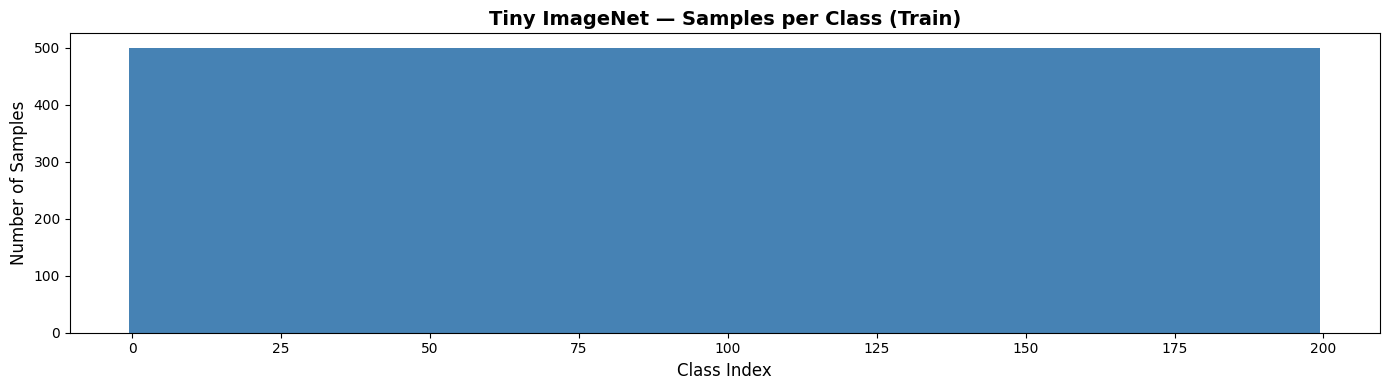

Samples per class: min=500, max=500, mean=500
→ Perfectly balanced dataset: True


In [3]:
labels = [label for _, label in dataset.samples]
counts = Counter(labels)

plt.figure(figsize=(14, 4))
plt.bar(counts.keys(), counts.values(), color='steelblue', width=1.0)
plt.xlabel('Class Index', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Tiny ImageNet — Samples per Class (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()

print(f"Samples per class: min={min(counts.values())}, max={max(counts.values())}, mean={np.mean(list(counts.values())):.0f}")
print(f"→ Perfectly balanced dataset: {min(counts.values()) == max(counts.values())}")

## 3. Sample Images Grid

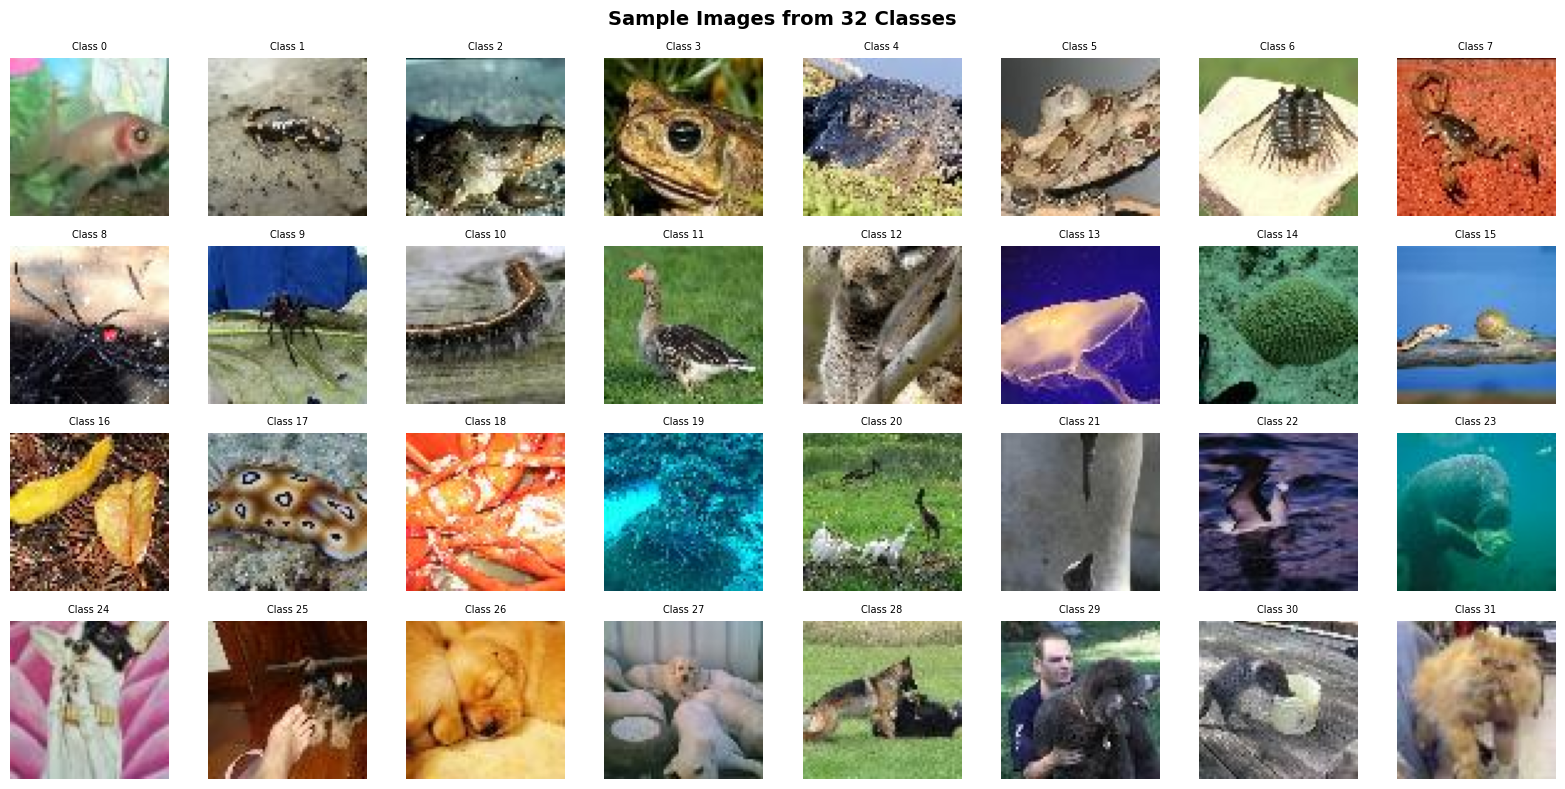

In [4]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

shown = set()
plot_idx = 0
for i in range(len(dataset)):
    img, label, idx = dataset[i]
    if label not in shown and plot_idx < 32:
        img_disp = denormalize(img).permute(1, 2, 0).numpy()
        axes[plot_idx].imshow(img_disp)
        axes[plot_idx].set_title(f'Class {label}', fontsize=7)
        axes[plot_idx].axis('off')
        shown.add(label)
        plot_idx += 1
    if plot_idx == 32:
        break

plt.suptitle('Sample Images from 32 Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/sample_grid.png', dpi=150)
plt.show()

## 4. Inject Label Corruption

We randomly flip 10% of training labels to simulate real-world annotation noise. We save the exact indices that were corrupted — this becomes our **ground truth** for evaluating the debugger later.

In [5]:
labels_override = corrupt_labels(
    dataset,
    corruption_rate=0.10,
    num_classes=200,
    seed=42,
    save_dir='../data/corrupted'
)

print(f"Total samples    : {len(dataset):,}")
print(f"Corrupted samples: {len(labels_override):,}")
print(f"Corruption rate  : {len(labels_override)/len(dataset)*100:.1f}%")
print(f"\n→ Each corrupted sample gets a random label from a different class")
print(f"→ Ground truth saved to data/corrupted/corruption_index.json")

[✓] Corrupted 10,000 / 100,000 samples (10%)
[✓] Corruption index saved to ../data/corrupted
Total samples    : 100,000
Corrupted samples: 10,000
Corruption rate  : 10.0%

→ Each corrupted sample gets a random label from a different class
→ Ground truth saved to data/corrupted/corruption_index.json


## 5. Visualize Corruption

The same image appears twice — once with its true label, once with the flipped label. This is exactly the kind of error our debugger needs to detect.

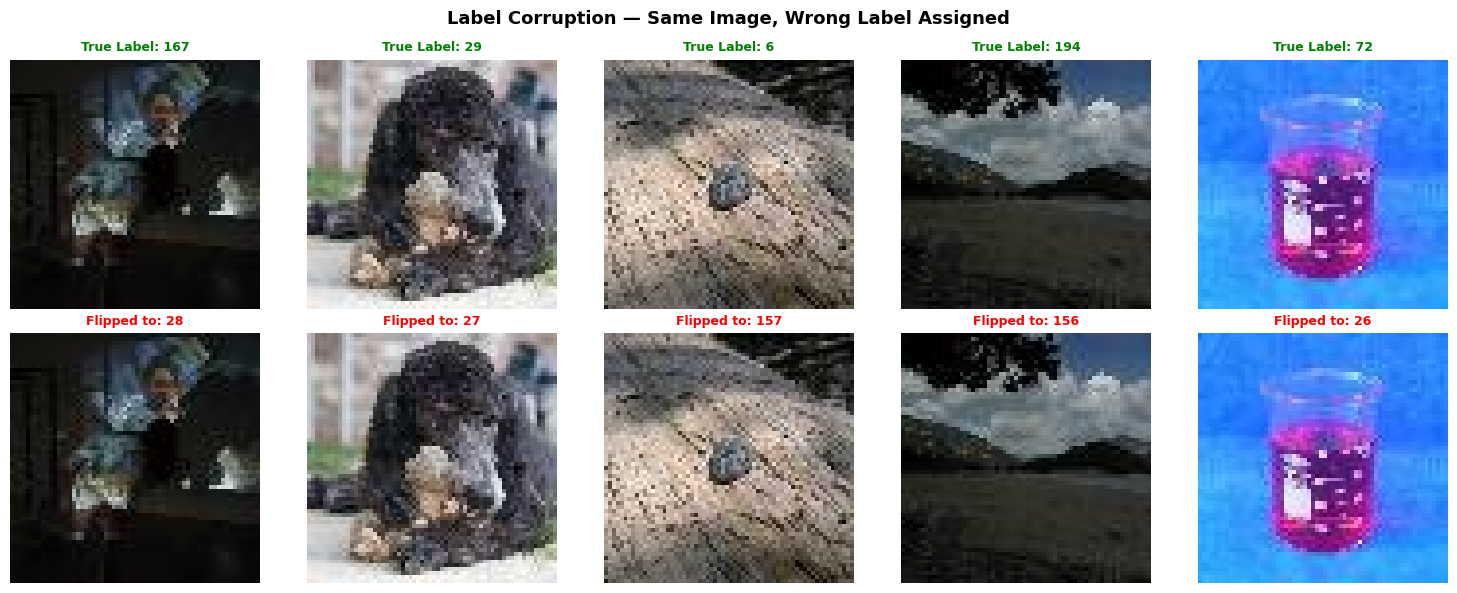

Key insight: The image content is unchanged — only the label is wrong.
A model trained on this data will struggle with these samples throughout training.


In [6]:
with open('../data/corrupted/corruption_index.json') as f:
    corruption_index = json.load(f)

sample_corrupted = [(int(k), v) for k, v in list(corruption_index.items())[:5]]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for col, (idx, entry) in enumerate(sample_corrupted):
    img, _, _ = dataset[idx]
    img_disp  = denormalize(img).permute(1, 2, 0).numpy()

    axes[0, col].imshow(img_disp)
    axes[0, col].set_title(f"True Label: {entry['original']}", fontsize=9, color='green', fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(img_disp)
    axes[1, col].set_title(f"Flipped to: {entry['corrupted']}", fontsize=9, color='red', fontweight='bold')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Corrupted', fontsize=10, fontweight='bold')
plt.suptitle('Label Corruption — Same Image, Wrong Label Assigned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/corruption_examples.png', dpi=150)
plt.show()

print(f"Key insight: The image content is unchanged — only the label is wrong.")
print(f"A model trained on this data will struggle with these samples throughout training.")

## 6. Summary

**Key findings from this notebook:**
- Dataset is perfectly balanced: 500 samples × 200 classes = 100,000 total
- 10,000 labels were randomly flipped (10% corruption rate)
- Corrupted samples look completely normal visually — only the label is wrong
- Ground truth corruption index saved for later evaluation